In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridsearch_arima import grid_search
from trainer_arima import train_arima

In [2]:
# LOAD DATA
df = pd.read_csv("WADI_clean.csv")

target = "3_LT_001_PV"

# features = tout sauf target
X = df.drop(columns=[target])

# Valeurs manquantes complétées
X = X.ffill()

y = df[target]

# garder que numérique
X = X.select_dtypes(include=[np.number])


# SPLIT (time series)
split_1 = int(len(df) * 0.7)
split_2 = int(len(df) * 0.85)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_val = X.iloc[split_1:split_2]
y_val = y.iloc[split_1:split_2]

X_test = X.iloc[split_2:]
y_test = y.iloc[split_2:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test :", X_test.shape)

Train: (142881, 120)
Validation: (30617, 120)
Test : (30618, 120)


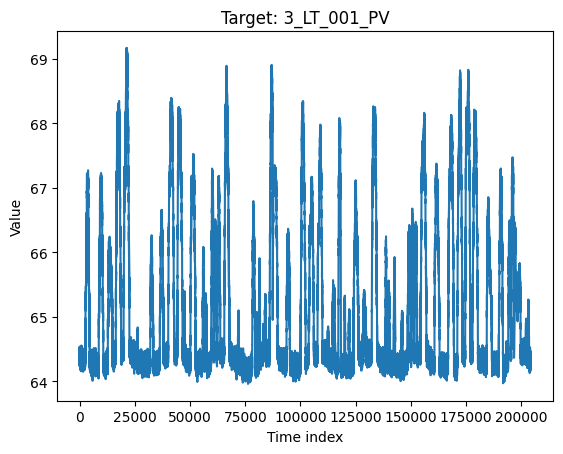

In [3]:
plt.figure()
plt.plot(y)
plt.title("Target: 3_LT_001_PV")
plt.xlabel("Time index")
plt.ylabel("Value")

plt.savefig("target_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Pas de variation d'amplitude : modèle additif.

In [4]:

from statsmodels.tsa.stattools import acf

def estimate_seasonality(series, max_lag=500, plot=False):
    """
    Estime la saisonnalité dominante via autocorrélation.

    Args:
        series (pd.Series ou np.array)
        max_lag (int): horizon max à tester
        plot (bool): option debug visuel

    Returns:
        int: lag saisonnier estimé
    """

    # nettoyage
    y = np.array(series)
    y = y[~np.isnan(y)]

    # autocorrélation
    autocorr = acf(y, nlags=max_lag, fft=True)

    # on ignore lag 0
    autocorr[0] = 0

    # on cherche les pics
    seasonality = np.argmax(autocorr)

    # sécurité : éviter lag trivial
    if seasonality < 2:
        seasonality = np.argmax(autocorr[10:]) + 10

    return int(seasonality)

In [5]:
estimate_seasonality(y)

10

In [6]:
p_grid = {"model_type": ["arima", "sarimax"],"s_window": [None]} # on commence sans STL
p_grid_stl = {"model_type": ["stl_arima", "stl_sarimax"], "s_window": [3,5,7,9,11,15]} # puis on regardera STL

In [7]:
df_results = grid_search(trainer=train_arima, y_train=y_train, y_val=y_val, X_train=X_train, X_val=X_val, p_grid=p_grid,
    score_opt="RMSE", n_jobs=-1)

print(df_results.sort_values("RMSE"))

GridSearch ARIMA lancé sur 2 combinaisons
Parallelisation avec n_jobs=-1


/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,0,2)(0,0,0)[0] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-packages/pmdarima/arima/arima.py", line 603, in fit
    self._fit(y, X, **fit_args)
  File "/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-packages/pmdarima/arima/arima.py", line 524, in _fit
    fit, self.arima_res_ = _fit_wrapper()
  File "/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-packages/pmdarima/arima/arima.py", line 489, in _fit_wrapper
    arima = sm.tsa.statespace.SARIMAX(
  File "/u2/users/cycle3/sipahimalani/.local/lib/python3.8/site-p


Best params:
model_type       arima
s_window          None
RMSE          1.627063
MAE           1.037942
Name: 0, dtype: object
  model_type s_window       RMSE       MAE
0      arima     None   1.627063  1.037942
1    sarimax     None  25.918429  6.854611


In [8]:
df_results = grid_search(trainer=train_arima, y_train=y_train, y_val=y_val, X_train=X_train, X_val=X_val, p_grid=p_grid_stl,
    score_opt="RMSE", n_jobs=-1)

print(df_results.sort_values("RMSE"))

GridSearch ARIMA lancé sur 12 combinaisons
Parallelisation avec n_jobs=-1


KeyboardInterrupt: 